# Bulk RNA-seq Preprocessing

Convert bulk RNA-seq data (`expression.h5`, `gene_list.txt`, `metadata.csv`) into the
CancerFoundation pipeline format (`vocab.json`, `obs.parquet`, `mapping.json`, `mem.map/`).

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, "./")

import h5py
import json
import os
import shutil
import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scanpy as sc

# Development

In [9]:
# Inputs and general settings
from pathlib import Path

# --- INPUT: bulk data files (in the same directory) ---
# BULK_DIR = Path("/cluster/work/boeva/bulkFM/data/processed/archs4")
BULK_DIR = Path("tutorials/archs4_test")
EXPRESSION_H5 = BULK_DIR / "expression.h5"
GENE_LIST_TXT = BULK_DIR / "gene_list.txt"
METADATA_CSV = BULK_DIR / "metadata.csv"

# --- OUTPUT: pipeline-ready processed data ---
OUTPUT_DIR = BULK_DIR / "h5ads"

# Optional: path to an existing vocab.json to reuse (set to None to generate from gene_list.txt)
EXISTING_VOCAB_PATH = None

# Metadata columns to include in obs.parquet (must exist in metadata.csv)
OBS_COLUMNS = ["tissue", "series_id", "sample_id", "total_counts"]

# How many samples per h5ad chunk (controls memory during conversion)
CHUNK_SIZE = 500

In [3]:
## Imports
import sys
sys.path.insert(0, "./")

import h5py
import json
import os
import shutil
import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
from bionemo.scdl.io.single_cell_collection import SingleCellCollection

from cancerfoundation.data.dataset import DatasetDir

GENE_ID = "_cf_gene_id"
CLS_TOKEN = "<cls>"
PAD_TOKEN = "<pad>"

## 1. Load bulk data

In [4]:
# Load gene list
with open(GENE_LIST_TXT) as f:
    gene_names = [line.strip() for line in f if line.strip()]

print(f"Genes: {len(gene_names)}")

# Load metadata
metadata = pd.read_csv(METADATA_CSV)
print(f"Samples in metadata: {len(metadata)}")
print(f"Columns: {list(metadata.columns)}")
metadata.head()

Genes: 67186
Samples in metadata: 1000
Columns: ['sample_id', 'geo_accession', 'tissue', 'series_id', 'total_counts', 'n_detected_genes']


,sample_id,geo_accession,tissue,series_id,total_counts,n_detected_genes
0,sample_000000,GSM_SYNTH_000000,unknown,GSE_SYNTH_000000,70714480.0,32704
1,sample_000001,GSM_SYNTH_000001,unknown,GSE_SYNTH_000000,58300224.0,32070
2,sample_000002,GSM_SYNTH_000002,unknown,GSE_SYNTH_000000,65226924.0,32713
3,sample_000003,GSM_SYNTH_000003,unknown,GSE_SYNTH_000000,72034816.0,33255
4,sample_000004,GSM_SYNTH_000004,unknown,GSE_SYNTH_000000,66846772.0,32888


In [5]:
# Inspect expression matrix shape without loading it all
with h5py.File(EXPRESSION_H5, "r") as f:
    print("Datasets in HDF5:", list(f.keys()))
    # Adapt the dataset key if needed (common keys: "expression", "data/expression", "X")
    for key in f.keys():
        ds = f[key]
        if hasattr(ds, "shape"):
            print(f"  {key}: shape={ds.shape}, dtype={ds.dtype}")

    # Determine the expression dataset key
    expr_key = "expression"  # adjust if your file uses a different key
    n_samples, n_genes_h5 = f[expr_key].shape
    print(f"\nExpression matrix: {n_samples} samples × {n_genes_h5} genes")
    assert n_genes_h5 == len(gene_names), (
        f"Gene count mismatch: h5 has {n_genes_h5}, gene_list.txt has {len(gene_names)}"
    )

Datasets in HDF5: ['expression']
  expression: shape=(1000, 67186), dtype=float32

Expression matrix: 1000 samples × 67186 genes


## 2. Convert expression matrix to chunked h5ad files

Each chunk becomes one h5ad file with:
- `.X`: sparse expression matrix (samples × genes)
- `.var_names`: gene symbols
- `.var["_cf_gene_id"]`: vocab indices per gene
- `.obs`: metadata columns from `metadata.csv`

These h5ad files are an intermediate step consumed by `SingleCellCollection`.

In [10]:
h5ad_dir = OUTPUT_DIR
h5ad_dir.mkdir(parents=True, exist_ok=True)

# Map gene names to vocab IDs; drop genes not in vocab
gene_ids = np.array([vocab.get(g, -1) for g in gene_names])
valid_mask = gene_ids >= 0
valid_gene_names = [g for g, v in zip(gene_names, valid_mask) if v]
valid_gene_ids = gene_ids[valid_mask]
valid_col_indices = np.where(valid_mask)[0]

print(f"Genes in vocab: {len(valid_gene_names)}/{len(gene_names)}")

# Use sample_id as index if available, else generate one
if "sample_id" in metadata.columns:
    metadata = metadata.set_index("sample_id", drop=False)

with h5py.File(EXPRESSION_H5, "r") as f:
    expr_ds = f[expr_key]
    n_total = expr_ds.shape[0]
    n_chunks = (n_total + CHUNK_SIZE - 1) // CHUNK_SIZE

    for chunk_idx in range(n_chunks):
        start = chunk_idx * CHUNK_SIZE
        end = min(start + CHUNK_SIZE, n_total)

        # Read chunk and select valid genes
        X_dense = expr_ds[start:end, :][:, valid_col_indices]
        X_sparse = sp.csr_matrix(X_dense.astype(np.float32))

        obs_chunk = metadata.iloc[start:end][OBS_COLUMNS].copy()
        obs_chunk.index = obs_chunk.index.astype(str)

        var = pd.DataFrame({GENE_ID: valid_gene_ids}, index=valid_gene_names)
        var[GENE_ID] = var[GENE_ID].astype(int)

        adata = ad.AnnData(X=X_sparse, obs=obs_chunk, var=var)

        fname = f"bulk_chunk_{chunk_idx:04d}.h5ad"
        adata.write_h5ad(h5ad_dir / fname)
        print(f"  [{chunk_idx+1}/{n_chunks}] wrote {fname}  ({end - start} samples)")

print(f"\nCreated {n_chunks} h5ad files in {h5ad_dir}")

Genes in vocab: 67186/67186
  [1/2] wrote bulk_chunk_0000.h5ad  (500 samples)
  [2/2] wrote bulk_chunk_0001.h5ad  (500 samples)

Created 2 h5ad files in tutorials/archs4_test/h5ads


## Synthetic data for testing

In [1]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd

# ===== User settings =====
input_h5 = Path("/cluster/work/boeva/bulkFM/data/processed/archs4/expression.h5")          # path to your full H5 file
output_dir = Path("tutorials/archs4_test")     # where to write the test files
dataset_name = "expression"               # HDF5 dataset name
n_samples = 1000                          # take only the first n samples
gene_prefix = "GENE"
sample_prefix = "sample"

output_dir.mkdir(parents=True, exist_ok=True)

subset_h5 = output_dir / "expression.h5"
gene_list_txt = output_dir / "gene_list.txt"
metadata_csv = output_dir / "metadata.csv"

with h5py.File(input_h5, "r") as f_in:
    ds = f_in[dataset_name]
    total_samples, n_genes = ds.shape
    n = min(n_samples, total_samples)

    print(f"Input shape: {total_samples} samples x {n_genes} genes")
    print(f"Taking subset: first {n} samples")

    # Load only the first n rows for testing
    X = ds[:n, :]

# Write subset H5
with h5py.File(subset_h5, "w") as f_out:
    f_out.create_dataset(
        dataset_name,
        data=X,
        compression="gzip",
        compression_opts=4,
        chunks=True,
    )

# Synthetic gene list
genes = [f"{gene_prefix}_{i:06d}" for i in range(n_genes)]
with open(gene_list_txt, "w", encoding="utf-8") as f:
    for g in genes:
        f.write(g + "\n")

# Synthetic metadata, but with real counts derived from the subset matrix
total_counts = X.sum(axis=1)
n_detected_genes = (X > 0).sum(axis=1)

metadata = pd.DataFrame({
    "sample_id": [f"{sample_prefix}_{i:06d}" for i in range(n)],
    "geo_accession": [f"GSM_SYNTH_{i:06d}" for i in range(n)],
    "tissue": ["unknown"] * n,
    "series_id": [f"GSE_SYNTH_{i // 100:06d}" for i in range(n)],
    "total_counts": total_counts.astype(float),
    "n_detected_genes": n_detected_genes.astype(int),
})

metadata.to_csv(metadata_csv, index=False)

print(f"\nWrote files to: {output_dir.resolve()}")
print(f"  - {subset_h5.name}")
print(f"  - {gene_list_txt.name}")
print(f"  - {metadata_csv.name}")

print("\nMetadata preview:")
display(metadata.head())

print("\nGene list preview:")
print(genes[:5])

Input shape: 617413 samples x 67186 genes
Taking subset: first 1000 samples

Wrote files to: /cluster/work/boeva/rquiles/CancerFoundation/tutorials/archs4_test
  - expression.h5
  - gene_list.txt
  - metadata.csv

Metadata preview:


,sample_id,geo_accession,tissue,series_id,total_counts,n_detected_genes
0,sample_000000,GSM_SYNTH_000000,unknown,GSE_SYNTH_000000,70714480.0,32704
1,sample_000001,GSM_SYNTH_000001,unknown,GSE_SYNTH_000000,58300224.0,32070
2,sample_000002,GSM_SYNTH_000002,unknown,GSE_SYNTH_000000,65226924.0,32713
3,sample_000003,GSM_SYNTH_000003,unknown,GSE_SYNTH_000000,72034816.0,33255
4,sample_000004,GSM_SYNTH_000004,unknown,GSE_SYNTH_000000,66846772.0,32888



Gene list preview:
['GENE_000000', 'GENE_000001', 'GENE_000002', 'GENE_000003', 'GENE_000004']


# Testing

In [4]:
def inspect_bulk_normalization(
    bulk_dir: Path | str,
    chunk_size: int = 10_000,
    expr_key: str = "expression",
    existing_vocab_path: Optional[Path] = None,
    norm_scale: int = 4,
):
    """Load only the first chunk of expression.h5, apply CP10K+log1p, and plot distributions."""
    BULK_DIR = Path(bulk_dir)
    EXPRESSION_H5 = BULK_DIR / "expression.h5"
    GENE_LIST_TXT = BULK_DIR / "gene_list.txt"
 
    assert EXPRESSION_H5.is_file(), f"Expression file not found: {EXPRESSION_H5}"
    assert GENE_LIST_TXT.is_file(), f"Gene list file not found: {GENE_LIST_TXT}"
 
    # Load gene list
    with open(GENE_LIST_TXT) as f:
        gene_names = [line.strip() for line in f if line.strip()]
    print(f"Genes: {len(gene_names)}")
 
    with h5py.File(EXPRESSION_H5, "r") as f:
        assert expr_key in list(f.keys()), (
            f"Expression key '{expr_key}' not found. Available keys: {list(f.keys())}"
        )
 
        n_samples, n_genes_h5 = f[expr_key].shape
        print(f"Expression matrix: {n_samples} samples × {n_genes_h5} genes")
        assert n_genes_h5 == len(gene_names), (
            f"Gene count mismatch: h5 has {n_genes_h5}, gene_list.txt has {len(gene_names)}"
        )
 
        # Map gene names to vocab IDs; drop genes not in vocab
        if existing_vocab_path is not None:
            with open(existing_vocab_path) as v:
                vocab = json.load(v)
            gene_ids = np.array([vocab.get(g, -1) for g in gene_names])
            valid_mask = gene_ids >= 0
            valid_col_indices = np.where(valid_mask)[0]
            print(f"Genes in vocab: {valid_mask.sum()}/{len(gene_names)}")
        else:
            valid_col_indices = None
 
        expr_ds = f[expr_key]
        end = min(chunk_size, n_samples)
 
        # Read first chunk and select valid genes
        X_dense = (
            expr_ds[:end, :][:, valid_col_indices]
            if valid_col_indices is not None
            else expr_ds[:end, :]
        )
        X_dense = np.asarray(X_dense, dtype=np.float64)
 
    print(f"\nFirst chunk shape: {X_dense.shape}")
 
    # --- Raw counts stats ---
    raw_flat = X_dense.flatten()
    raw_nonzero = raw_flat[raw_flat > 1]
    print("\n--- Raw counts ---")
    print(f"Min:    {raw_flat.min():.4f}")
    print(f"Max:    {raw_flat.max():.4f}")
    print(f"Mean:   {raw_flat.mean():.4f}")
    print(f"Median: {np.median(raw_flat):.4f}")
    print(f"% zeros: {(raw_flat == 0).mean():.2%}")
    print(f"Row sums (first 10): {X_dense.sum(axis=1)[:10]}")
 
    # --- Apply CP10K + log1p normalization ---
    library_size = X_dense.sum(axis=1, keepdims=True)
    library_size[library_size == 0] = 1.0
    X_norm = X_dense / library_size * 10 ** norm_scale
    X_norm = np.log1p(X_norm)
 
    norm_flat = X_norm.flatten()
    norm_nonzero = norm_flat[norm_flat > 1]
    print("\n--- Normalized ---")
    print(f"Min:    {norm_flat.min():.4f}")
    print(f"Max:    {norm_flat.max():.4f}")
    print(f"Mean:   {norm_flat.mean():.4f}")
    print(f"Median: {np.median(norm_flat):.4f}")
    print(f"% zeros: {(norm_flat == 0).mean():.2%}")
 
    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
    # Raw counts (nonzero)
    log1p_raw_nonzero = np.log1p(raw_nonzero)
    log1p_raw_nonzero = log1p_raw_nonzero[log1p_raw_nonzero > 4]
    axes[0].hist(log1p_raw_nonzero, bins=200, color="coral", edgecolor="none")
    axes[0].set_xlabel("Raw counts")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution (raw counts, nonzero)")
    
    # Normalized (log1p), nonzero
    axes[1].hist(norm_nonzero, bins=200, color="steelblue", edgecolor="none")
    axes[1].set_xlabel("log1p(CP10K)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Distribution (normalized, nonzero)")
 
    plt.tight_layout()
    plt.show()

    # Explicitly free memory before returning
    del X_dense, X_norm, raw_flat, norm_flat, raw_nonzero, norm_nonzero
    import gc
    gc.collect()
 
    return None

## CPM

Genes: 67186
Expression matrix: 719432 samples × 67186 genes

First chunk shape: (50, 67186)

--- Raw counts ---
Min:    0.0000
Max:    2193760.0000
Mean:   436.9676
Median: 0.0000
% zeros: 58.69%
Row sums (first 10): [70714473. 58300222. 65226925. 72034813. 66846773. 59968330.   519638.
   599381.   621721.   511022.]

--- Normalized ---
Min:    0.0000
Max:    12.9384
Mean:   0.6049
Median: 0.0000
% zeros: 58.69%


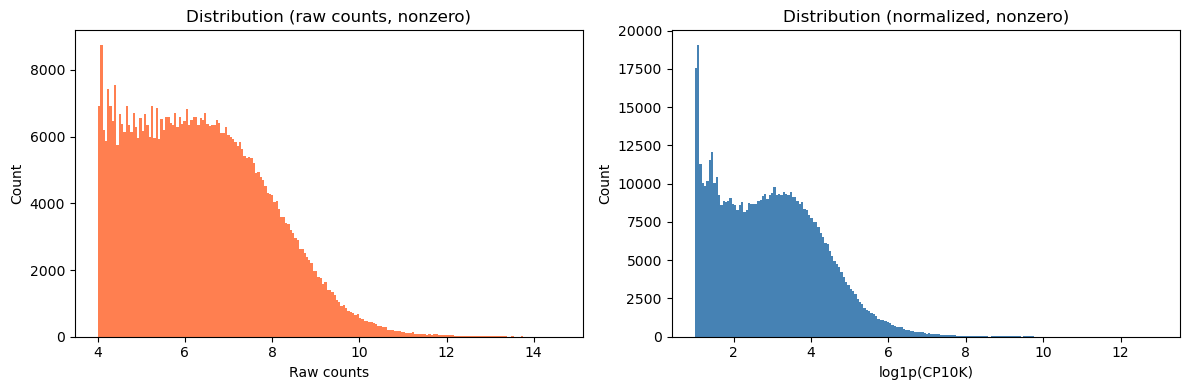

In [33]:
inspect_bulk_normalization( \
    bulk_dir="/cluster/work/boeva/rquiles/bulkFM-data/data/processed/archs4", \
    chunk_size=50, \
    expr_key="expression", \
    existing_vocab_path=None, \
)

## CP10K

Genes: 67186
Expression matrix: 719432 samples × 67186 genes

First chunk shape: (50, 67186)

--- Raw counts ---
Min:    0.0000
Max:    2193760.0000
Mean:   436.9676
Median: 0.0000
% zeros: 58.69%
Row sums (first 10): [70714473. 58300222. 65226925. 72034813. 66846773. 59968330.   519638.
   599381.   621721.   511022.]

--- Normalized ---
Min:    0.0000
Max:    8.3335
Mean:   0.0557
Median: 0.0000
% zeros: 58.69%


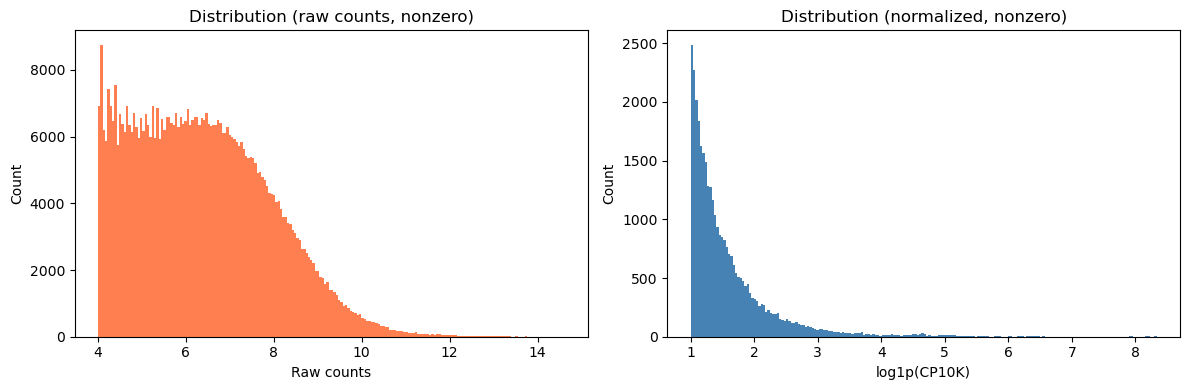

In [35]:
inspect_bulk_normalization( \
    bulk_dir="/cluster/work/boeva/rquiles/bulkFM-data/data/processed/archs4", \
    chunk_size=50, \
    expr_key="expression", \
    existing_vocab_path=None, \
)

# Check Files

In [2]:
bulk_file = "/cluster/work/boeva/rquiles/data/paired_dataset/pipeline_ready/h5ads/bulk_chunk_0003.h5ad"
bulk_paired_file = "/cluster/work/boeva/rquiles/data/paired_dataset/pipeline_ready/h5ads/paired_bulk_chunk_0011.h5ad"
pb_paired_file = "/cluster/work/boeva/rquiles/data/paired_dataset/pipeline_ready/h5ads/paired_pb_chunk_0013.h5ad"

bulk = sc.read_h5ad(bulk_file)
bulk_paired = sc.read_h5ad(bulk_paired_file)
pb_paired = sc.read_h5ad(pb_paired_file)

In [3]:
def asses_distrib(adata):
    # Get values
    values = adata.X[:100, :50000].toarray().flatten()
    
    # Only non-zero values (sparse data)
    nonzero = values[values > 1]
    
    print(f"Min:    {values.min():.4f}")
    print(f"Max:    {values.max():.4f}")
    print(f"Mean:   {values.mean():.4f}")
    print(f"Median: {np.median(values):.4f}")
    print(f"% zeros: {(values == 0).mean():.2%}")
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    # Log1p scale (as stored)
    ax.hist(nonzero, bins=200, color="steelblue", edgecolor="white")
    ax.set_xlabel("log1p(expression)")
    ax.set_ylabel("Count")
    ax.set_title("Distribution (log1p scale)")
    ax.set_xlim(0, np.percentile(nonzero, 99.9))
    
    plt.tight_layout()
    plt.show()

### Bulk

Min:    0.0000
Max:    13.0544
Mean:   0.4783
Median: 0.0000
% zeros: 81.74%


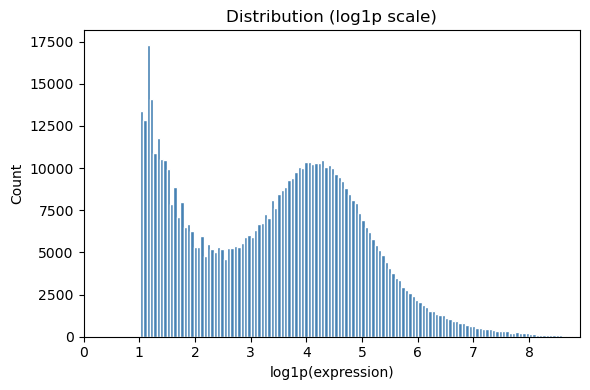

In [4]:
asses_distrib(bulk)

### Paired Bulk

Min:    0.0000
Max:    10.8420
Mean:   0.6530
Median: 0.0000
% zeros: 56.97%


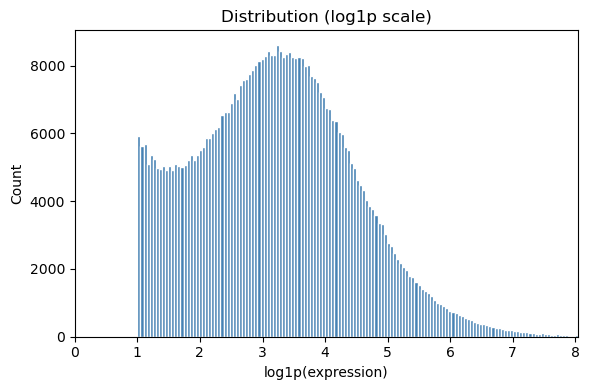

In [5]:
asses_distrib(bulk_paired)

### Paired Pseudobulk

Min:    0.0000
Max:    11.8019
Mean:   0.6671
Median: 0.0000
% zeros: 70.34%


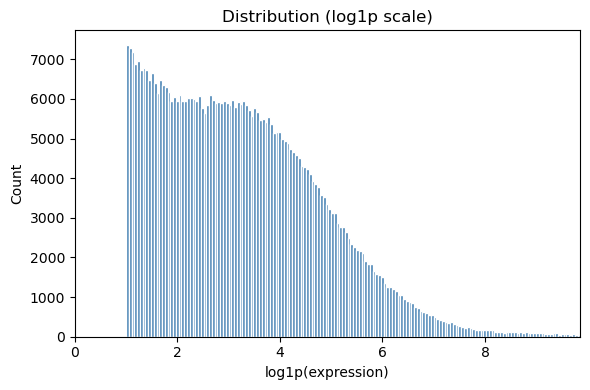

In [6]:
asses_distrib(pb_paired)